In [8]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..','src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from DiagnosisTool.features import clean_diabetes_data

module_path = os.path.abspath(os.path.join(module_path,'DiagnosisTool'))

if module_path not in sys.path:
    sys.path.append(module_path)

from data import download_diabetes_file
from data import load_diabetes_data

download_diabetes_file()

diabetes_data = load_diabetes_data()

diabetes_data = clean_diabetes_data(diabetes_data)

diabetes_data.describe()




Dataset URL: https://www.kaggle.com/datasets/mathchi/diabetes-data-set
Dataset URL: https://www.kaggle.com/datasets/mathchi/diabetes-data-set


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


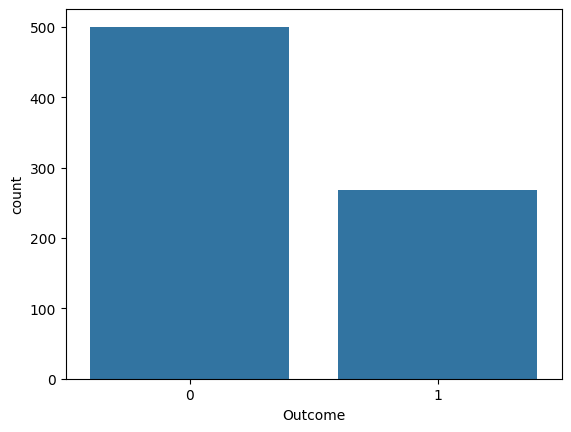

In [9]:
sns.countplot(x="Outcome", data=diabetes_data)
plt.title="Distribuição da variável Outcome"
plt.show()


### Discussão sobre Métricas de Outcome
- Normalmente observa-se <b>desbalanceamento moderado</b>
- Classe 0 (não diabético) costuma ser maior que Classe 1
- Isso impacta
    - Métricas de avaliação
    - Escolha de modelos
    - Possivelmente técnicas de balanceamento

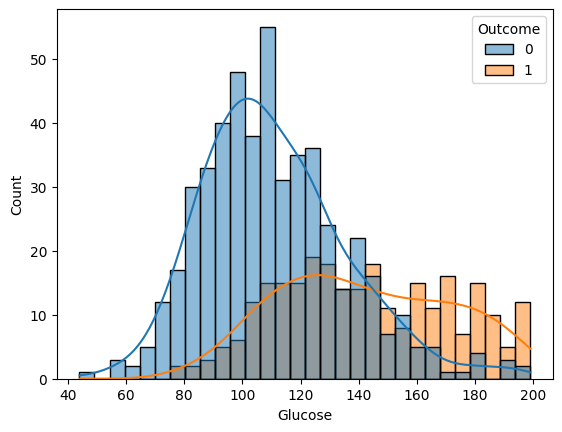

In [10]:
sns.histplot(data=diabetes_data, x="Glucose", hue="Outcome", kde=True, bins=30)
plt.title="Distribuição de Glucose por Classe"
plt.show()



### Discussão sobre Glucose por Classe
- Indivíduos com <b>Diabetes (Outcome = 1)</b> tendem a ter:
    - Médias mais altas de Glucose
    - Distribuição deslocada à direita
- Forte indicador preditivo

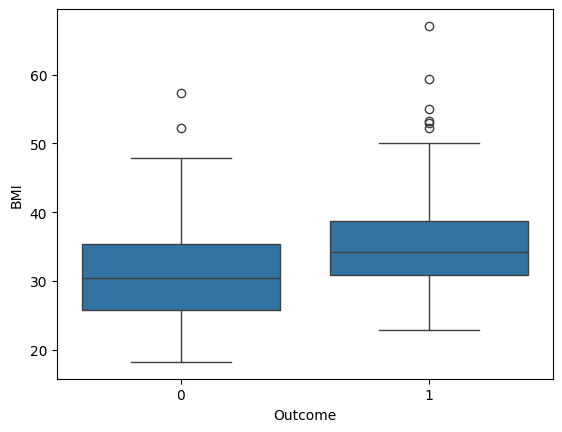

In [11]:
sns.boxplot(x="Outcome",y="BMI",data=diabetes_data)
plt.title="BMI por Classe"
plt.show()



### Discussão sobre BMI vs. Outcome
- Classe <b>diabética</b> costuma apresentar:
    - BMI médio mais alto
    - Maior variabilidade
- Relação positiva entre diabetes e obesidade é consistente com literatura médica
    

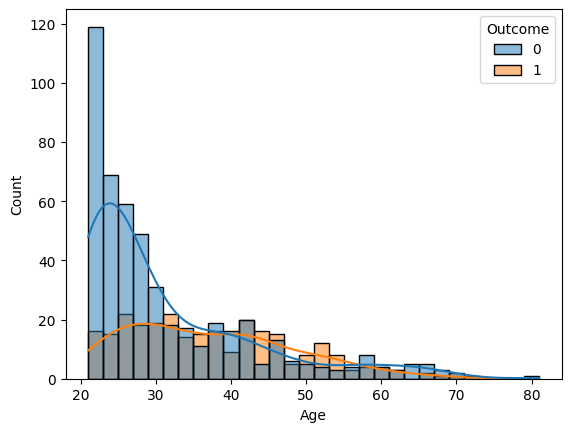

In [12]:
sns.histplot(data=diabetes_data, x="Age", hue="Outcome", kde=True, bins=30)
plt.title="Distribuição de Age por Classe"
plt.show()




### Discussão sobre Idade vs. Outcome
- Maior incidência de diabetes sobre idades mais altas
- Distribuição mais concentrada em faixas etárias superiores para Outcome = 1
- Idade deve ser considerada uma feature importante

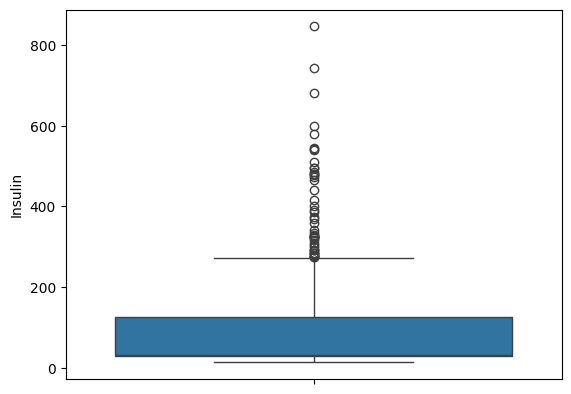

In [13]:
sns.boxplot(y="Insulin",data=diabetes_data)
plt.title="Distribuição de Insulin"
plt.show()



### Discussão sobre Insulina e Skin Thickness (atenção especial)
- Distribuição altamente assimétrica
- Presença de:
    - Muitos zeros
    - Outliers extremos
- Antes de usar no modelo:
    - Substituir zeros por NaN
    - Aplicar imputação
    - Possivelmente usar transformação logarítmica


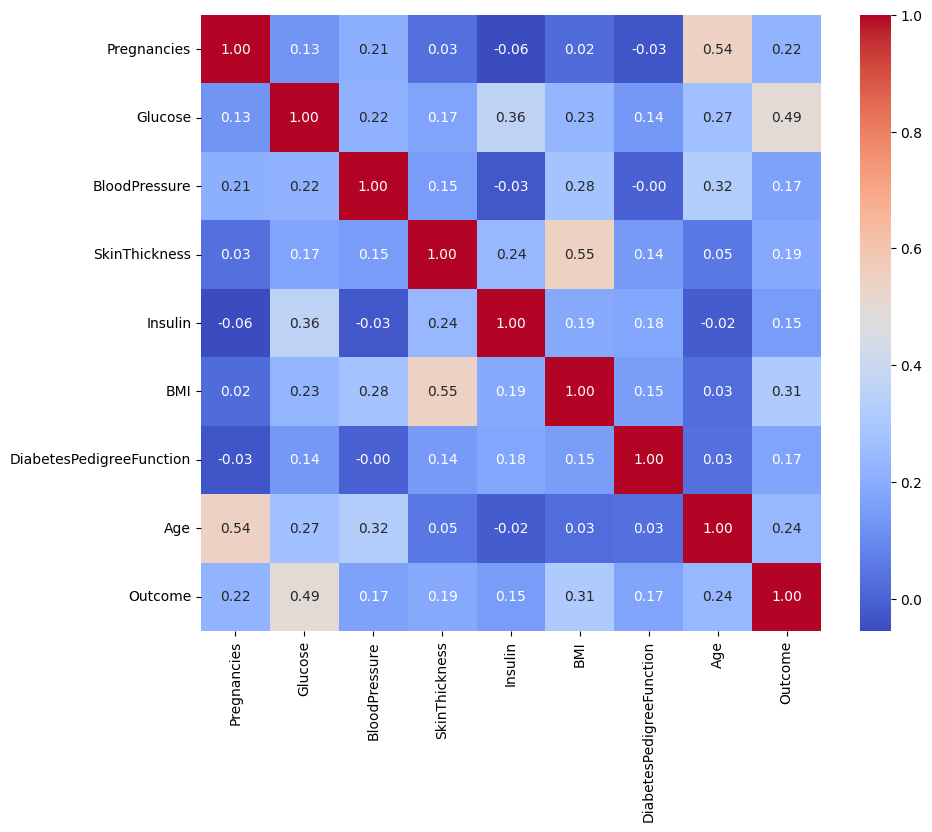

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(diabetes_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title="Matriz de Correlação"
plt.show()

### Pontos relevantes
- Glucose costuma ter a maior correlação com Outcome
- BMI e Idade também mostram correlação positiva
- Pouca multicolinearidade severa

### Discussão Geral dos resultados
#### Principais insights
- Glucose é a feature mais informativa
    - Clara separação entre as classes
- BMI e Idade são fateores de risco importantes
    - Coerente com evidências clínicas
- Zeros representam dados ausentes
    - Devem ser tratados antes do treinamento
- Dataset é relativamente pequeno
    - Modelos simples podem funcionar bem
    - Validação cruzada é recomendada